# WM 2026 — Match-Vorhersage & Tor-zu-Tor-Analyse

**Begleit-Notebook zu** *Soccer Analytics with Machine Learning* (O'Reilly, 2026).

Dieses Notebook beantwortet zwei Fragen direkt aus den Daten und zeigt die
Ergebnisse in Tabellen und Grafiken:

1. **Sieg / Unentschieden / Niederlage** — für jedes denkbare Match liefern
   *elf* Modelle eine `P(Sieg) / P(Unentschieden) / P(Niederlage)`.
2. **Tor-zu-Tor (genaues Ergebnis)** — die Poisson-/Negative-Binomial-Modelle
   rechnen intern die *vollständige Ergebnis-Matrix* `P[Heimtore, Gasttore]`.
   Hier machen wir diese Matrix sichtbar: Korrekt-Ergebnis-Heatmap,
   wahrscheinlichste Resultate, erwartete Tore (λ), Über/Unter & BTTS.

Zum Schluss simulieren wir das **gesamte Turnier** (48 Teams) und ermitteln die
Titelwahrscheinlichkeiten.

> ⚠️ **Hinweis:** Die Team-Stärken (`STRENGTH`) und Markt-Quoten sind ein
> *illustrativer Snapshot* (Stand früh 2026). Vor einer Veröffentlichung mit
> aktuellen Elo-Werten (z. B. *eloratings.net*) auffrischen — der Code bleibt gleich.

Alle Modelle werden auf **358 echten Länderspielen** kalibriert
(WM 2010–2022 + EM 2020/2024).


## 1. Setup

Imports, ein einheitlicher Farbpalette/Stil für schöne Grafiken, und ein fester
Zufallsseed für reproduzierbare Ergebnisse.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import poisson as pois, nbinom
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import log_loss, accuracy_score
try:
    from xgboost import XGBClassifier; HAS_XGB = True
except Exception:
    HAS_XGB = False

rng = np.random.default_rng(7)
DATA = Path("data")

# ---- a coherent visual theme -------------------------------------------------
NAVY, RED, GREEN, AMBER, GREY = "#1E2761", "#B85042", "#2E7D5B", "#E0A040", "#8A8D93"
WDL_COLORS = {"Sieg": GREEN, "Unentschieden": AMBER, "Niederlage": RED}
SCORE_CMAP = LinearSegmentedColormap.from_list("wc", ["#F7F9FC", "#9FB6D6", NAVY])
mpl.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlesize": 13,
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
})
print("Setup OK · XGBoost verfügbar:", HAS_XGB)

Setup OK · XGBoost verfügbar: True


## 2. Das Teilnehmerfeld, die Stärke-Werte und die echten Spiele

Die ausgeloste Gruppenphase 2026, ein Elo-artiger Stärke-Snapshot pro Team und
358 reale Länderspiele, auf denen alle Modelle kalibriert werden.

In [2]:
GROUPS = {
    "A": ["Mexico","South Africa","South Korea","Czechia"],
    "B": ["Canada","Bosnia-Herzegovina","Qatar","Switzerland"],
    "C": ["Brazil","Morocco","Haiti","Scotland"],
    "D": ["United States","Paraguay","Australia","Türkiye"],
    "E": ["Germany","Curacao","Ivory Coast","Ecuador"],
    "F": ["Netherlands","Japan","Sweden","Tunisia"],
    "G": ["Belgium","Egypt","Iran","New Zealand"],
    "H": ["Spain","Cape Verde","Saudi Arabia","Uruguay"],
    "I": ["France","Senegal","Iraq","Norway"],
    "J": ["Argentina","Algeria","Austria","Jordan"],
    "K": ["Portugal","Congo DR","Uzbekistan","Colombia"],
    "L": ["England","Croatia","Ghana","Panama"],
}
TEAMS = [t for g in GROUPS.values() for t in g]

# Elo-artiger Stärke-Snapshot (48 Teilnehmer + historische Teams nur fürs Training)
STRENGTH = {
    "Spain":2165,"Argentina":2120,"France":2100,"England":2055,"Brazil":2025,"Netherlands":2030,
    "Portugal":2010,"Germany":1965,"Belgium":1950,"Croatia":1945,"Uruguay":1930,"Colombia":1915,
    "Morocco":1900,"Japan":1900,"Senegal":1895,"Switzerland":1860,"Norway":1855,"Austria":1850,
    "Ecuador":1840,"Türkiye":1840,"Mexico":1820,"Czechia":1815,"Sweden":1815,"United States":1805,
    "Iran":1800,"Ivory Coast":1800,"Algeria":1795,"South Korea":1790,"Scotland":1780,"Egypt":1780,
    "Canada":1780,"Ghana":1750,"Paraguay":1720,"Australia":1720,"Congo DR":1720,"Bosnia-Herzegovina":1710,
    "Tunisia":1700,"Qatar":1680,"Uzbekistan":1680,"Saudi Arabia":1655,"Iraq":1650,"Panama":1650,
    "South Africa":1640,"Jordan":1600,"Cape Verde":1555,"Curacao":1530,"Haiti":1500,"New Zealand":1500,
    "Italy":1990,"Denmark":1870,"Poland":1825,"Serbia":1820,"Chile":1815,"Russia":1815,"Nigeria":1810,
    "Ukraine":1800,"Greece":1800,"Hungary":1795,"Wales":1790,"Cameroon":1760,"Slovakia":1760,
    "Slovenia":1760,"Romania":1755,"Peru":1750,"Iceland":1740,"Georgia":1735,"Albania":1730,
    "North Macedonia":1720,"Finland":1715,"Costa Rica":1700,"Honduras":1620,"North Korea":1600,
}
# Aktuelle Außenseiter-/Titelquoten (amerikanisch) — nur als Benchmark (Ch9)
FUTURES_AMERICAN = {
    "Spain":+430,"France":+500,"England":+650,"Brazil":+800,"Argentina":+950,"Germany":+1100,
    "Portugal":+1200,"Netherlands":+1400,"Belgium":+2200,"Croatia":+3300,"Uruguay":+3300,
    "Morocco":+4000,"Colombia":+4000,"Japan":+5000,"Senegal":+6600,"Switzerland":+8000,
}
print(f"{len(TEAMS)} Teilnehmer in {len(GROUPS)} Gruppen.")

48 Teilnehmer in 12 Gruppen.


In [3]:
def load_matches():
    wc = pd.read_csv(DATA/"worldcup_matches.csv")
    ri = pd.read_csv(DATA/"recent_internationals.csv")
    cols = ["home_team","away_team","home_score","away_score","knockout"]
    m = pd.concat([wc[cols], ri[cols]], ignore_index=True)
    m = m[m.home_team.isin(STRENGTH) & m.away_team.isin(STRENGTH)].copy()
    m["sdiff"]   = m.home_team.map(STRENGTH) - m.away_team.map(STRENGTH)  # Stärkedifferenz
    m["sum_elo"] = m.home_team.map(STRENGTH) + m.away_team.map(STRENGTH)
    m["ko"]      = m.knockout.astype(str).str.upper().eq("TRUE").astype(int)
    m["res"]     = np.sign(m.home_score - m.away_score).astype(int)       # -1 / 0 / +1
    m["y"]       = m.res + 1                                              # 0=Gast,1=Remis,2=Heim
    return m.reset_index(drop=True)

M = load_matches()
print(f"Trainingsbasis: {len(M)} echte Länderspiele "
      f"({(M.res==1).mean()*100:.0f}% Heim-/Erstgenannter-Siege, "
      f"{(M.res==0).mean()*100:.0f}% Unentschieden, "
      f"{(M.res==-1).mean()*100:.0f}% Auswärtssiege).")
M.head()

Trainingsbasis: 358 echte Länderspiele (38% Heim-/Erstgenannter-Siege, 27% Unentschieden, 35% Auswärtssiege).


,home_team,away_team,home_score,away_score,knockout,sdiff,sum_elo,ko,res,y
0,South Africa,Mexico,1,1,False,-180,3460,0,0,1
1,Uruguay,France,0,0,False,-170,4030,0,0,1
2,South Africa,Uruguay,0,3,False,-290,3570,0,-1,0
3,France,Mexico,0,2,False,280,3920,0,-1,0
4,Mexico,Uruguay,0,1,False,-110,3750,0,-1,0


### Stärke-Ranking der 48 Teilnehmer (Snapshot)

In [4]:
rank = (pd.DataFrame({"Team": TEAMS, "Stärke": [STRENGTH[t] for t in TEAMS]})
          .sort_values("Stärke", ascending=False).reset_index(drop=True))
rank.index += 1
(rank.head(16).style
    .format({"Stärke": "{:.0f}"})
    .background_gradient(cmap="YlGnBu", subset=["Stärke"])
    .set_caption("Top 16 nach Stärke-Snapshot (Elo-Skala)"))

,Team,Stärke
1,Spain,2165
2,Argentina,2120
3,France,2100
4,England,2055
5,Netherlands,2030
6,Brazil,2025
7,Portugal,2010
8,Germany,1965
9,Belgium,1950
10,Croatia,1945


## 3. Modell-Kalibrierung auf echten Spielen

**Poisson-Tormodell.** Wir modellieren die erzielten Tore eines Teams als
Funktion der Stärkedifferenz `sdiff = Stärke(A) − Stärke(B)`:

$$\lambda = \exp(\beta_0 + \beta_1 \cdot \text{sdiff})$$

Jedes echte Spiel liefert *zwei* Beobachtungen (die Sicht jeder Mannschaft).
Zusätzlich passen wir die **Negative-Binomial-Streuung** (für realistischere
Tor-Varianz) und ein **Remis-Modell** `P(Remis) ~ |sdiff|` an.

In [5]:
# Poisson-GLM: Tore ~ Stärkedifferenz (zwei Zeilen je Spiel)
gl  = pd.DataFrame({"goals": np.r_[M.home_score, M.away_score],
                    "sd":    np.r_[M.sdiff, -M.sdiff]})
glX = sm.add_constant(gl[["sd"]])
pois_fit = sm.GLM(gl.goals, glX, family=sm.families.Poisson()).fit()
B0, B1 = pois_fit.params["const"], pois_fit.params["sd"]
alpha  = max(1e-3, (pois_fit.pearson_chi2/pois_fit.df_resid - 1))  # NB-Dispersion

def lam(a, b):
    '''Erwartete Tore (lambda_a, lambda_b) fuer A vs B aus der Staerkedifferenz.'''
    d = STRENGTH[a] - STRENGTH[b]
    return float(np.exp(B0 + B1*d)), float(np.exp(B0 - B1*d))

# Remis-Modell: P(Remis) ~ |sdiff|  (für die Rating-Modelle)
dz = sm.add_constant(pd.DataFrame({"abs": M.sdiff.abs()}))
draw_fit = sm.GLM((M.res==0).astype(int), dz, family=sm.families.Binomial()).fit()
def pdraw(absd):
    return float(draw_fit.predict(sm.add_constant(pd.DataFrame({"abs":[absd]}),
                                                  has_constant="add"))[0])

EGD_PER   = B1*np.exp(B0)*2            # erwartete Tordiff. je Stärkepunkt (Skala)
SCORE_GRID = np.arange(0, 11)         # 0..10 Tore
print(f"Poisson:  λ = exp({B0:.3f} + {B1:.5f} · sdiff)")
print(f"          → 0 Diff: {np.exp(B0):.2f} Tore | +200 Stärke: {np.exp(B0+B1*200):.2f} Tore")
print(f"Negative-Binomial-Dispersion  α = {alpha:.3f}")
print(f"Remis-Rate bei Gleichstärke:  {pdraw(0)*100:.1f}%  | bei +300:  {pdraw(300)*100:.1f}%")

Poisson:  λ = exp(0.167 + 0.00164 · sdiff)
          → 0 Diff: 1.18 Tore | +200 Stärke: 1.64 Tore
Negative-Binomial-Dispersion  α = 0.008
Remis-Rate bei Gleichstärke:  29.0%  | bei +300:  25.1%


**Kalibrierungs-Check.** Links: erwartete Tore (λ) als Funktion der
Stärkedifferenz, mit den echten Spielen als Punktwolke. Rechts: die
Remis-Wahrscheinlichkeit fällt mit wachsendem Stärkeunterschied — genau wie
erwartet.

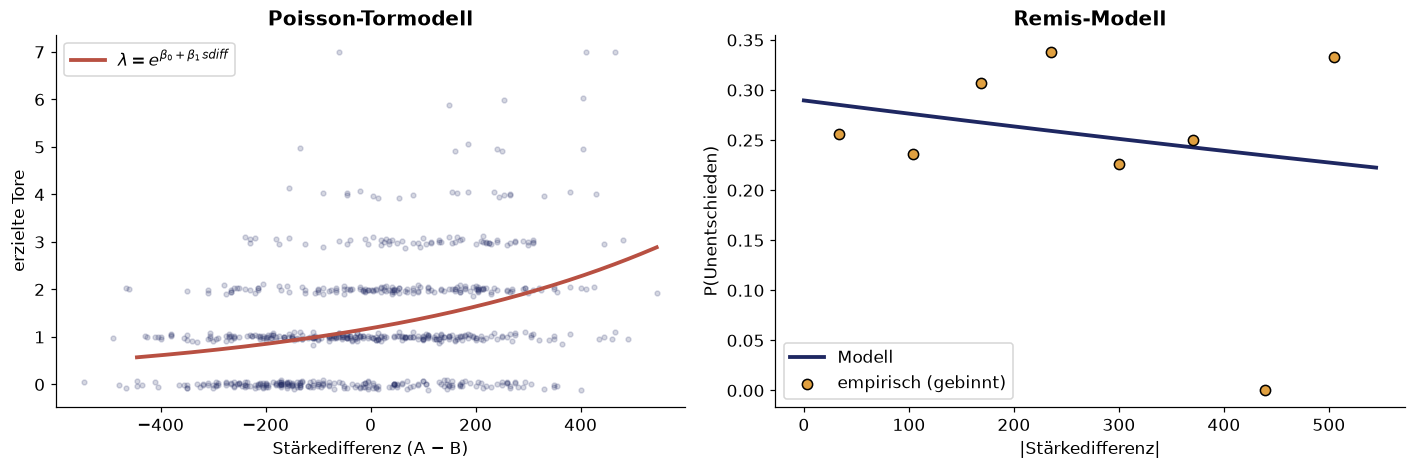

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))

xs = np.linspace(M.sdiff.min(), M.sdiff.max(), 200)
ax1.scatter(gl.sd, gl.goals + rng.normal(0, .05, len(gl)), s=10, alpha=.18, color=NAVY)
ax1.plot(xs, np.exp(B0 + B1*xs), color=RED, lw=2.5, label=r"$\lambda = e^{\beta_0+\beta_1\,sdiff}$")
ax1.set(xlabel="Stärkedifferenz (A − B)", ylabel="erzielte Tore",
        title="Poisson-Tormodell"); ax1.legend()

ad = np.linspace(0, M.sdiff.abs().max(), 200)
emp = (M.assign(ab=M.sdiff.abs())
        .groupby(pd.cut(M.sdiff.abs(), bins=8))
        .apply(lambda d: pd.Series({"x": d.sdiff.abs().mean(), "p": (d.res==0).mean()})))
ax2.plot(ad, [pdraw(v) for v in ad], color=NAVY, lw=2.5, label="Modell")
ax2.scatter(emp.x, emp.p, s=45, color=AMBER, edgecolor="k", zorder=3, label="empirisch (gebinnt)")
ax2.set(xlabel="|Stärkedifferenz|", ylabel="P(Unentschieden)",
        title="Remis-Modell"); ax2.legend()
plt.tight_layout(); plt.savefig("nb_calibration.png"); plt.show()

# Teil A — Sieg / Unentschieden / Niederlage

Hier ist die **Match-Vorhersage**, nach der gefragt wurde: für jedes Match eine
`P(Sieg) / P(Remis) / P(Niederlage)` — und zwar aus **elf** verschiedenen
Modellen, damit man die Bandbreite sieht.

* **Tormodelle** (Poisson, NegBin) leiten W/D/N aus der Ergebnis-Matrix ab.
* **Klassifikatoren** (Logit, KNN, RandomForest, XGBoost, neuronales Netz)
  werden direkt auf den 358 Spielen trainiert, das Ziel zu klassifizieren.
* **Rating-Modelle** (Elo, Colley, PageRank) nutzen eine Sieg-Erwartungskurve
  plus das Remis-Modell.

### 4.1 Klassifikatoren trainieren (5-fache Kreuzvalidierung)

In [7]:
feat_cols = ["sdiff","sum_elo","ko"]
X, yv = M[feat_cols].values, M.y.values
clf_defs = {
    "logit": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, C=1.0)),
    "knn":   make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=30)),
    "rf":    RandomForestClassifier(n_estimators=400, max_depth=5, min_samples_leaf=8, random_state=1),
    "nn":    make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(16,8), max_iter=3000, random_state=1)),
}
clf_defs["xgb"] = (XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                                 subsample=0.9, colsample_bytree=0.9, eval_metric="mlogloss",
                                 random_state=1) if HAS_XGB else
                   GradientBoostingClassifier(n_estimators=250, max_depth=3, learning_rate=0.05, random_state=1))
clf_classes, cv_rows = {}, []
for name, clf in clf_defs.items():
    pp = cross_val_predict(clf, X, yv, cv=5, method="predict_proba")
    cv_rows.append({"Modell": name, "CV LogLoss": log_loss(yv, pp, labels=[0,1,2]),
                    "CV Accuracy": accuracy_score(yv, pp.argmax(1))})
    clf.fit(X, yv); clf_classes[name] = (clf, list(clf.classes_))
cv = pd.DataFrame(cv_rows).sort_values("CV LogLoss").reset_index(drop=True)
(cv.style.format({"CV LogLoss":"{:.3f}","CV Accuracy":"{:.1%}"})
   .background_gradient(cmap="RdYlGn_r", subset=["CV LogLoss"])
   .background_gradient(cmap="RdYlGn",  subset=["CV Accuracy"])
   .set_caption("Klassifikator-Güte (5-fache CV auf 358 echten Spielen)"))

,Modell,CV LogLoss,CV Accuracy
0,logit,1.001,54.2%
1,rf,1.011,55.6%
2,knn,1.013,52.5%
3,nn,1.115,52.5%
4,xgb,1.169,48.3%


### 4.2 Rating-Systeme (Colley & PageRank) aus den Ergebnissen

In [8]:
def elo_winexp(da):                       # da = Stärkedifferenz (a−b)
    return 1.0/(1.0 + 10**(-da/400.0))

def colley_ratings():
    teams = sorted(set(M.home_team)|set(M.away_team)); idx={t:i for i,t in enumerate(teams)}
    n=len(teams); C=np.eye(n)*2; b=np.ones(n)
    for _,r in M.iterrows():
        i,j=idx[r.home_team],idx[r.away_team]
        C[i,i]+=1; C[j,j]+=1; C[i,j]-=1; C[j,i]-=1
        wi = 1.0 if r.res>0 else (0.5 if r.res==0 else 0.0)
        b[i]+=wi-0.5; b[j]+=(1-wi)-0.5
    r=np.linalg.solve(C,b); return {t:r[idx[t]] for t in teams}

def pagerank_ratings(d=0.85, it=100):
    teams=sorted(set(M.home_team)|set(M.away_team)); idx={t:i for i,t in enumerate(teams)}
    n=len(teams); W=np.zeros((n,n))
    for _,r in M.iterrows():
        i,j=idx[r.home_team],idx[r.away_team]
        if r.res>0:   W[j,i]+=1
        elif r.res<0: W[i,j]+=1
        else:         W[i,j]+=0.5; W[j,i]+=0.5
    cs=W.sum(1,keepdims=True); cs[cs==0]=1; T=W/cs; pr=np.ones(n)/n
    for _ in range(it): pr=(1-d)/n + d*(T.T@pr)
    return {t:pr[idx[t]] for t in teams}

def to_elo_scale(ratings):
    vals=np.array(list(ratings.values())); mu,sd=vals.mean(), vals.std()+1e-9
    return {t: (1850+(ratings[t]-mu)/sd*130) if t in ratings else STRENGTH[t] for t in TEAMS}

COLLEY = to_elo_scale(colley_ratings())
PAGER  = to_elo_scale(pagerank_ratings())
print("Colley/PageRank berechnet. Beispiel — Colley(Spain) =", round(COLLEY['Spain'],0))

Colley/PageRank berechnet. Beispiel — Colley(Spain) = 2100.0


### 4.3 Eine Funktion: W/D/N aus *jedem* Modell

`wdl_all_models("Spain", "Morocco")` liefert für genau dieses Match die
Sieg/Remis/Niederlage-Wahrscheinlichkeit aus allen elf Modellen.

In [9]:
def _grid_wdl(la, lb, nb=False):
    '''W/D/N aus der vollstaendigen Tor-Matrix (Poisson oder Negative Binomial).'''
    def pmf(l):
        if nb and alpha > 1e-6:
            rr = 1.0/alpha; return nbinom.pmf(SCORE_GRID, rr, rr/(rr+l))
        return pois.pmf(SCORE_GRID, l)
    P = np.outer(pmf(la), pmf(lb))
    pw = np.tril(P,-1).sum(); pl = np.triu(P,1).sum(); pd_ = np.trace(P)
    s  = pw+pl+pd_;  return pw/s, pd_/s, pl/s

def wdl_all_models(a, b):
    rows = {}
    la, lb = lam(a, b)
    rows["poisson"] = _grid_wdl(la, lb, nb=False)
    rows["negbin"]  = _grid_wdl(la, lb, nb=True)
    for key, S in [("elo", STRENGTH), ("colley", COLLEY), ("pagerank", PAGER)]:
        da = S[a]-S[b]; we = elo_winexp(da); pdr = pdraw(abs(da))
        rows[key] = ((1-pdr)*we, pdr, (1-pdr)*(1-we))
    feat = np.array([[STRENGTH[a]-STRENGTH[b], STRENGTH[a]+STRENGTH[b], 0]], float)
    for key,(clf,classes) in clf_classes.items():
        p = clf.predict_proba(feat)[0]; cidx={c:k for k,c in enumerate(classes)}
        rows[key] = (p[cidx.get(2,0)], p[cidx.get(1,0)], p[cidx.get(0,0)])
    df = pd.DataFrame(rows, index=["Sieg","Unentschieden","Niederlage"]).T * 100
    df.index.name = "Modell"
    return df

demo = wdl_all_models("Spain", "Morocco")
(demo.style.format("{:.1f}%")
     .background_gradient(cmap="Greens",  subset=["Sieg"])
     .background_gradient(cmap="Oranges", subset=["Unentschieden"])
     .background_gradient(cmap="Reds",    subset=["Niederlage"])
     .set_caption("Spanien vs. Marokko — Sieg/Remis/Niederlage je Modell (%)"))

,Sieg,Unentschieden,Niederlage
Modell,,,
poisson,62.6%,22.3%,15.2%
negbin,62.4%,22.3%,15.3%
elo,61.1%,25.6%,13.3%
colley,57.0%,26.2%,16.8%
pagerank,69.3%,23.9%,6.8%
logit,61.2%,24.0%,14.7%
knn,46.7%,26.7%,26.7%
rf,39.9%,38.6%,21.5%
nn,56.0%,19.6%,24.4%


### 4.4 Mehrere Schlüsselspiele im Vergleich (Grafik)

Pro Match ein gestapelter Balken je Modell — grün=Sieg, gelb=Remis, rot=Niederlage
(aus Sicht des erstgenannten Teams). So sieht man sofort, wo sich die Modelle
einig sind und wo nicht.

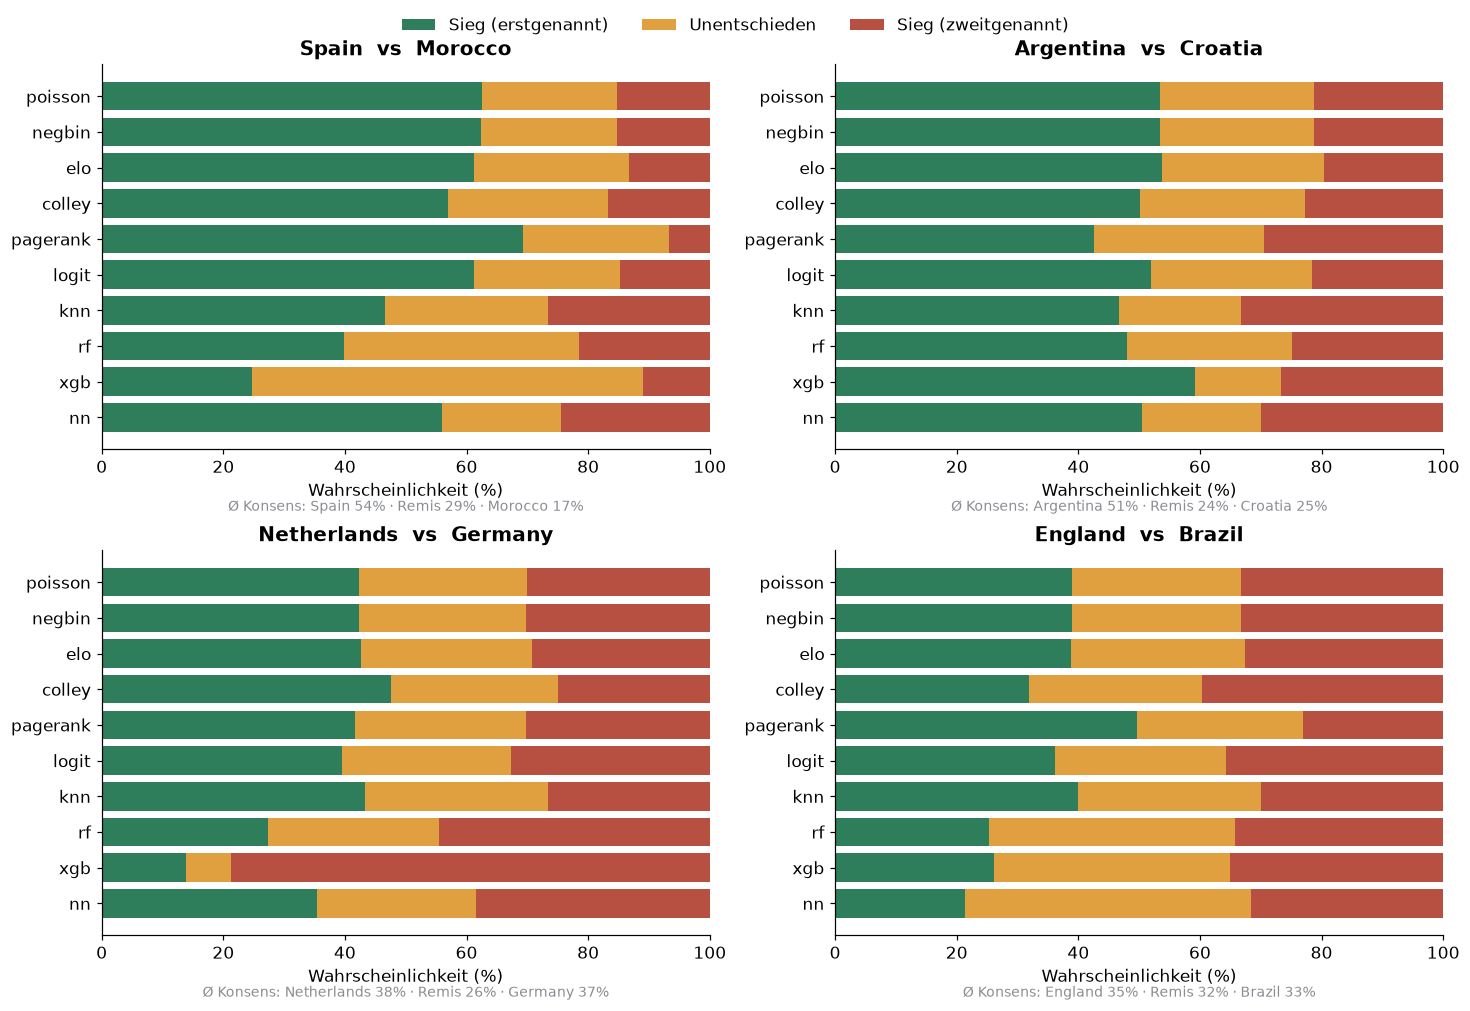

In [10]:
MATCHUPS = [("Spain","Morocco"), ("Argentina","Croatia"),
            ("Netherlands","Germany"), ("England","Brazil")]
order = ["poisson","negbin","elo","colley","pagerank","logit","knn","rf","xgb","nn"]

fig, axes = plt.subplots(2, 2, figsize=(13.5, 9)); axes = axes.ravel()
for ax,(a,b) in zip(axes, MATCHUPS):
    d = wdl_all_models(a, b).reindex(order)
    y = np.arange(len(d))
    ax.barh(y, d["Sieg"], color=GREEN, label="Sieg "+a)
    ax.barh(y, d["Unentschieden"], left=d["Sieg"], color=AMBER, label="Unentschieden")
    ax.barh(y, d["Niederlage"], left=d["Sieg"]+d["Unentschieden"], color=RED, label="Sieg "+b)
    ax.set_yticks(y); ax.set_yticklabels(d.index); ax.invert_yaxis()
    ax.set_xlim(0,100); ax.set_xlabel("Wahrscheinlichkeit (%)")
    ax.set_title(f"{a}  vs  {b}")
    cons = d.mean()
    ax.text(0.5, -0.16, f"Ø Konsens: {a} {cons['Sieg']:.0f}% · "
            f"Remis {cons['Unentschieden']:.0f}% · {b} {cons['Niederlage']:.0f}%",
            transform=ax.transAxes, ha="center", fontsize=9, color=GREY)
handles,_ = axes[0].get_legend_handles_labels()
fig.legend(["Sieg (erstgenannt)","Unentschieden","Sieg (zweitgenannt)"],
           loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout(); plt.savefig("nb_wdl_matchups.png"); plt.show()

### 4.5 Sieg-Wahrscheinlichkeits-Matrix (Top-Teams gegeneinander)

Konsens-`P(Sieg)` (Mittel über alle Modelle) für jedes Duell der stärksten
Teams. Zeile schlägt Spalte: dunkler = höhere Siegchance des Zeilen-Teams.

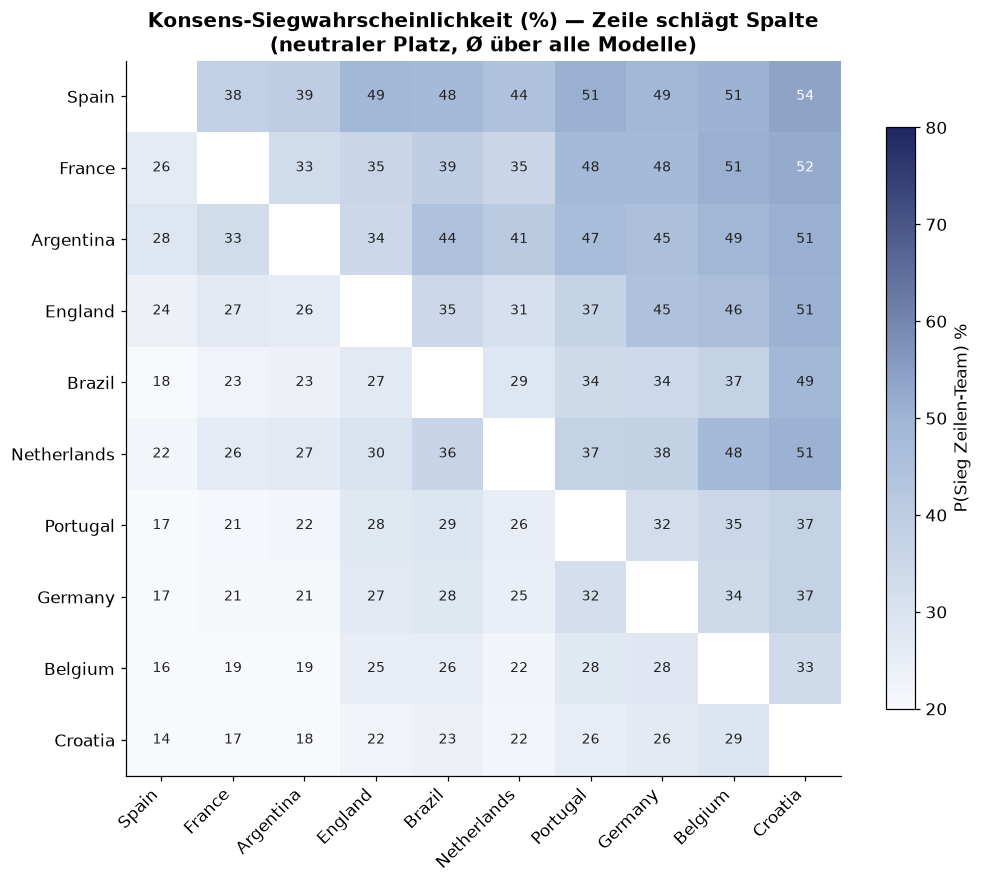

In [11]:
TOP = ["Spain","France","Argentina","England","Brazil","Netherlands",
       "Portugal","Germany","Belgium","Croatia"]
W = np.full((len(TOP), len(TOP)), np.nan)
for i,a in enumerate(TOP):
    for j,b in enumerate(TOP):
        if i!=j: W[i,j] = wdl_all_models(a,b)["Sieg"].mean()

fig, ax = plt.subplots(figsize=(9.5, 8))
im = ax.imshow(W, cmap=SCORE_CMAP, vmin=20, vmax=80)
ax.set_xticks(range(len(TOP))); ax.set_xticklabels(TOP, rotation=45, ha="right")
ax.set_yticks(range(len(TOP))); ax.set_yticklabels(TOP)
for i in range(len(TOP)):
    for j in range(len(TOP)):
        if i!=j:
            ax.text(j, i, f"{W[i,j]:.0f}", ha="center", va="center",
                    color="white" if W[i,j]>52 else "#222", fontsize=9)
ax.set_title("Konsens-Siegwahrscheinlichkeit (%) — Zeile schlägt Spalte\n(neutraler Platz, Ø über alle Modelle)")
fig.colorbar(im, ax=ax, shrink=.8, label="P(Sieg Zeilen-Team) %")
plt.tight_layout(); plt.savefig("nb_wdl_matrix.png"); plt.show()

# Teil B — Tor-zu-Tor-Analyse (genaues Ergebnis)

Das ist die **exakte Ergebnis-Analyse**. Das Poisson-Modell gibt jedem Team eine
erwartete Toranzahl λ. Die Wahrscheinlichkeit eines konkreten Resultats
*Heim h : Gast a* ist dann

$$P(h, a) = \text{Poisson}(h \mid \lambda_A) \cdot \text{Poisson}(a \mid \lambda_B).$$

Diese **vollständige Matrix** rechnet das Repo intern — wir machen sie hier
sichtbar: als Korrekt-Ergebnis-Heatmap, als Liste der wahrscheinlichsten
Resultate und als abgeleitete Wettmärkte (Über/Unter, BTTS).

In [12]:
def scoreline_matrix(a, b, model="poisson", maxg=7):
    '''Vollstaendige Ergebnis-Matrix P[heim_tore, gast_tore] fuer A vs B.'''
    la, lb = lam(a, b)
    def pmf(l):
        if model == "negbin" and alpha > 1e-6:
            rr = 1.0/alpha; return nbinom.pmf(np.arange(maxg+1), rr, rr/(rr+l))
        return pois.pmf(np.arange(maxg+1), l)
    P = np.outer(pmf(la), pmf(lb)); P /= P.sum()
    return P, la, lb

def match_report(a, b, model="poisson"):
    '''Alle Tor-zu-Tor-Kennzahlen fuer ein Match als Dict.'''
    P, la, lb = scoreline_matrix(a, b, model)
    n = P.shape[0]; I, J = np.indices(P.shape)
    pw, pd_, pl = np.tril(P,-1).sum(), np.trace(P), np.triu(P,1).sum()
    flat = sorted(((P[i,j], i, j) for i in range(n) for j in range(n)), reverse=True)
    top = [(f"{i}:{j}", p*100) for p,i,j in flat[:8]]
    tot = I + J
    return {
        "P": P, "lam": (la, lb), "wdl": (pw*100, pd_*100, pl*100),
        "top_scores": top,
        "modal": top[0][0],
        "over25": P[tot >= 3].sum()*100,
        "under25": P[tot <= 2].sum()*100,
        "btts": P[(I>=1) & (J>=1)].sum()*100,
        "exp_total": float((P*tot).sum()),
    }

### 5.1 Korrekt-Ergebnis-Heatmap

Jede Zelle = Wahrscheinlichkeit dieses exakten Endstands. Das **wahrscheinlichste
Ergebnis** ist umrandet. Felder unter der Diagonale = Heimsieg, Diagonale =
Remis, darüber = Auswärtssieg.

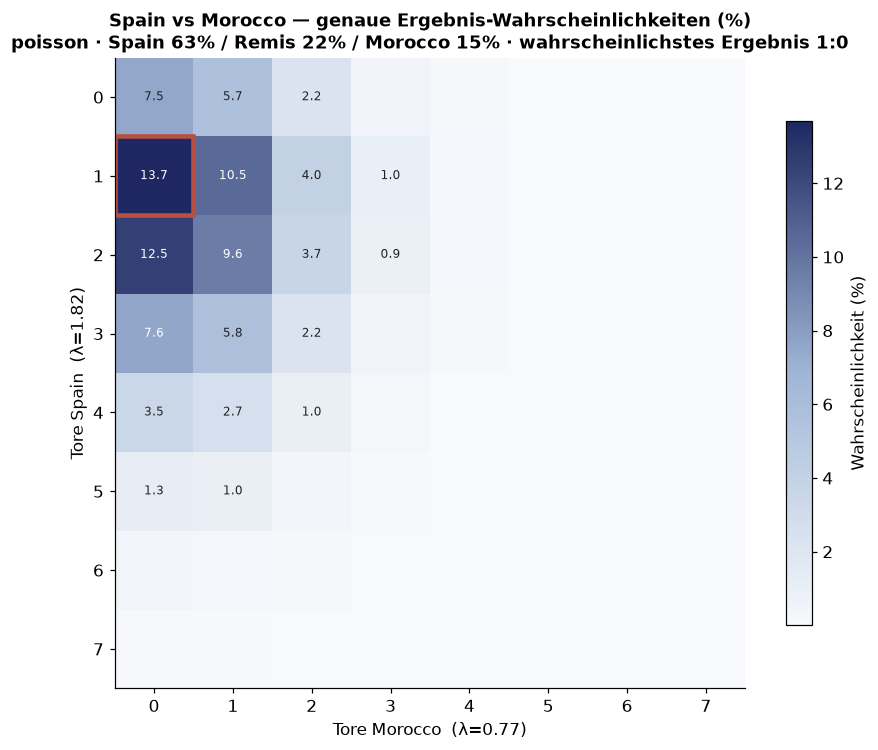

In [13]:
def plot_scoreline(a, b, model="poisson"):
    rep = match_report(a, b, model); P = rep["P"]; la, lb = rep["lam"]
    n = P.shape[0]
    fig, ax = plt.subplots(figsize=(8.2, 6.8))
    im = ax.imshow(P*100, cmap=SCORE_CMAP, origin="upper")
    for i in range(n):
        for j in range(n):
            v = P[i,j]*100
            if v >= 0.8:
                ax.text(j, i, f"{v:.1f}", ha="center", va="center",
                        color="white" if v > P.max()*100*0.55 else "#222", fontsize=8)
    mi, mj = divmod(int(np.argmax(P)), n)
    ax.add_patch(plt.Rectangle((mj-0.5, mi-0.5), 1, 1, fill=False, edgecolor=RED, lw=3))
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xlabel(f"Tore {b}  (λ={lb:.2f})"); ax.set_ylabel(f"Tore {a}  (λ={la:.2f})")
    pw,pdr,pl = rep["wdl"]
    ax.set_title(f"{a} vs {b} — genaue Ergebnis-Wahrscheinlichkeiten (%)\n"
                 f"{model} · {a} {pw:.0f}% / Remis {pdr:.0f}% / {b} {pl:.0f}% · "
                 f"wahrscheinlichstes Ergebnis {rep['modal']}", fontsize=12)
    fig.colorbar(im, ax=ax, shrink=.8, label="Wahrscheinlichkeit (%)")
    plt.tight_layout(); plt.savefig(f"nb_scoreline_{a}_{b}.png".replace(" ","_")); plt.show()
    return rep

rep_sm = plot_scoreline("Spain", "Morocco", "poisson")

### 5.2 Wahrscheinlichste Resultate & abgeleitete Märkte

In [14]:
def report_table(a, b, model="poisson"):
    rep = match_report(a, b, model)
    top = pd.DataFrame(rep["top_scores"], columns=[f"Ergebnis ({a}:{b})", "Wahrsch. %"])
    la, lb = rep["lam"]; pw,pdr,pl = rep["wdl"]
    summary = pd.DataFrame({
        "Kennzahl": ["Erwartete Tore "+a, "Erwartete Tore "+b, "Erwartete Tore gesamt",
                     f"Sieg {a}", "Unentschieden", f"Sieg {b}",
                     "Über 2.5 Tore", "Unter 2.5 Tore", "Beide treffen (BTTS)",
                     "Wahrscheinlichstes Ergebnis"],
        "Wert": [f"{la:.2f}", f"{lb:.2f}", f"{rep['exp_total']:.2f}",
                 f"{pw:.1f}%", f"{pdr:.1f}%", f"{pl:.1f}%",
                 f"{rep['over25']:.1f}%", f"{rep['under25']:.1f}%", f"{rep['btts']:.1f}%",
                 rep["modal"]],
    })
    return top, summary

top_sm, sum_sm = report_table("Spain", "Morocco", "poisson")
display(top_sm.style.hide(axis="index").format({"Wahrsch. %":"{:.1f}"})
        .background_gradient(cmap="Blues", subset=["Wahrsch. %"])
        .set_caption("Top-8 wahrscheinlichste Endstände"))
display(sum_sm.style.hide(axis="index").set_caption("Abgeleitete Match-Kennzahlen"))

Ergebnis (Spain:Morocco),Wahrsch. %
1:0,13.7
2:0,12.5
1:1,10.5
2:1,9.6
3:0,7.6
0:0,7.5
3:1,5.8
0:1,5.7


Kennzahl,Wert
Erwartete Tore Spain,1.82
Erwartete Tore Morocco,0.77
Erwartete Tore gesamt,2.59
Sieg Spain,62.5%
Unentschieden,22.3%
Sieg Morocco,15.2%
Über 2.5 Tore,47.9%
Unter 2.5 Tore,52.1%
Beide treffen (BTTS),44.9%
Wahrscheinlichstes Ergebnis,1:0


### 5.3 Poisson vs. Negative Binomial — Verteilung der Gesamttore

Die Negative-Binomial-Variante erlaubt mehr Streuung (Übersteuerung). Hier der
Vergleich der Verteilung der **Gesamttoranzahl** für dasselbe Match.

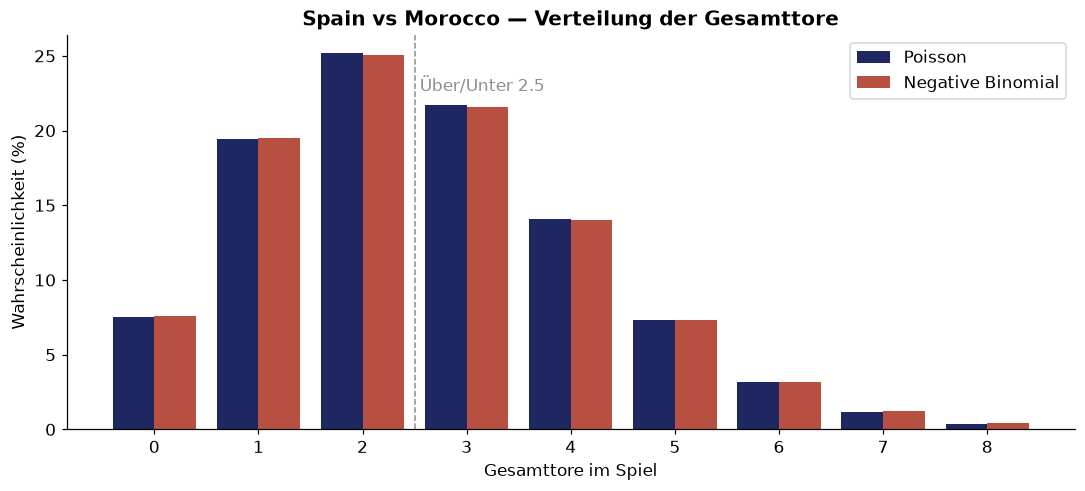

In [15]:
def total_goals_dist(a, b, model, maxg=9):
    P,_,_ = scoreline_matrix(a, b, model, maxg=maxg)
    tot = np.add.outer(np.arange(maxg+1), np.arange(maxg+1))
    return np.array([P[tot==k].sum() for k in range(2*maxg+1)])

a, b = "Spain", "Morocco"; K = np.arange(0, 9)
dp = total_goals_dist(a,b,"poisson")[:9]*100
dn = total_goals_dist(a,b,"negbin")[:9]*100
fig, ax = plt.subplots(figsize=(10, 4.6)); w=0.4
ax.bar(K-w/2, dp, w, label="Poisson", color=NAVY)
ax.bar(K+w/2, dn, w, label="Negative Binomial", color=RED)
ax.axvline(2.5, color=GREY, ls="--", lw=1); ax.text(2.55, max(dp)*0.9, "Über/Unter 2.5", color=GREY)
ax.set_xticks(K); ax.set_xlabel("Gesamttore im Spiel"); ax.set_ylabel("Wahrscheinlichkeit (%)")
ax.set_title(f"{a} vs {b} — Verteilung der Gesamttore"); ax.legend()
plt.tight_layout(); plt.savefig("nb_total_goals.png"); plt.show()

### 5.4 Alle 72 Gruppenspiele — wahrscheinlichstes Ergebnis je Algorithmus

Für jedes der **72 Gruppenspiele** (12 Gruppen × 6 Partien) das
**wahrscheinlichste exakte Ergebnis** und dessen Wahrscheinlichkeit — pro
**Algorithmus in eigenen Spalten** (Poisson, Negative Binomial, Colley, PageRank).

> Nur **Tormodelle** liefern exakte Ergebnisse. Die reinen W/U/N-Klassifikatoren
> (Logit, KNN, RandomForest, XGBoost, NN) sagen *keine* Tore voraus und tauchen
> hier daher nicht auf. **Elo** nutzt denselben Stärke-Input wie Poisson und
> liefert identische Ergebnisse — deshalb nicht doppelt aufgeführt. Colley und
> PageRank speisen ihre aus den Resultaten *berechneten* Ratings in dieselbe
> Tor-Kennlinie, weichen also stellenweise ab.

In [16]:
def scoreline_from_ratings(a, b, ratings, dispersion=0.0, maxg=7):
    """Ergebnis-Matrix aus beliebigen Team-Ratings via dieselbe Poisson-Tor-Kennlinie."""
    d = ratings[a] - ratings[b]
    la, lb = float(np.exp(B0 + B1*d)), float(np.exp(B0 - B1*d))
    g = np.arange(maxg+1)
    def pmf(l):
        if dispersion > 1e-6:
            rr = 1.0/dispersion; return nbinom.pmf(g, rr, rr/(rr+l))
        return pois.pmf(g, l)
    P = np.outer(pmf(la), pmf(lb)); P /= P.sum()
    return P, la, lb

def modal_score(a, b, ratings, dispersion=0.0):
    """Wahrscheinlichstes exaktes Ergebnis als h:a plus Wahrscheinlichkeit in Prozent."""
    P, la, lb = scoreline_from_ratings(a, b, ratings, dispersion)
    n = P.shape[0]; i, j = divmod(int(np.argmax(P)), n)
    return f"{i}:{j}", P[i, j]*100

# scoreline-fähige Algorithmen:  Name -> (Rating-Dict, Dispersion)
SCORE_ALGOS = {
    "Poisson":   (STRENGTH, 0.0),
    "Neg.Binom": (STRENGTH, alpha),
    "Colley":    (COLLEY,   0.0),
    "PageRank":  (PAGER,    0.0),
}

rows = []
for grp, teams in GROUPS.items():
    for x in range(4):
        for y in range(x+1, 4):
            a, b = teams[x], teams[y]
            row = {("Spiel", "Gr."): grp, ("Spiel", "Begegnung"): f"{a} – {b}"}
            for nm, (R, disp) in SCORE_ALGOS.items():
                s, p = modal_score(a, b, R, disp)
                row[(nm, "Erg.")] = s
                row[(nm, "P%")]   = round(p, 1)
            rows.append(row)
group_scores = pd.DataFrame(rows)
group_scores.columns = pd.MultiIndex.from_tuples(group_scores.columns)
group_scores.to_csv("group_match_scorelines.csv", index=False)

erg_cols = [(nm, "Erg.") for nm in SCORE_ALGOS]
agree = int((group_scores[erg_cols].nunique(axis=1) == 1).sum())
print(f"{len(group_scores)} Gruppenspiele · gespeichert -> group_match_scorelines.csv")
print(f"In {agree}/{len(group_scores)} Spielen sind sich alle vier Algorithmen "
      f"beim exakten Ergebnis einig.")

pcols = [(nm, "P%") for nm in SCORE_ALGOS]
(group_scores.style.hide(axis="index")
   .format({c: "{:.1f}" for c in pcols})
   .background_gradient(cmap="Blues", subset=pcols)
   .set_caption("Wahrscheinlichstes exaktes Ergebnis je Gruppenspiel und Algorithmus "
                "(P% = Wahrscheinlichkeit genau dieses Ergebnisses, neutraler Platz)"))


72 Gruppenspiele · gespeichert -> group_match_scorelines.csv
In 27/72 Spielen sind sich alle vier Algorithmen beim exakten Ergebnis einig.


### 5.5 Gestaffelt — die drei wahrscheinlichsten Ergebnisse je Spiel (Poisson)

Statt nur des Top-Ergebnisses hier die **Top 3** je Partie, nach
Wahrscheinlichkeit gestaffelt, plus die erwarteten Tore λ.

In [17]:
def top_scores(a, b, ratings=STRENGTH, dispersion=0.0, k=3):
    """Top-k wahrscheinlichste exakte Ergebnisse plus erwartete Tore."""
    P, la, lb = scoreline_from_ratings(a, b, ratings, dispersion)
    n = P.shape[0]
    flat = sorted(((P[i, j], i, j) for i in range(n) for j in range(n)), reverse=True)
    return [(f"{i}:{j}", p*100) for p, i, j in flat[:k]], la, lb

rows = []
for grp, teams in GROUPS.items():
    for x in range(4):
        for y in range(x+1, 4):
            a, b = teams[x], teams[y]
            tops, la, lb = top_scores(a, b, k=3)
            row = {"Gr.": grp, "Begegnung": f"{a} – {b}", "λ (erw. Tore)": f"{la:.2f} : {lb:.2f}"}
            for r, (s, p) in enumerate(tops, 1):
                row[f"{r}. Ergebnis"] = f"{s}   ({p:.0f}%)"
            rows.append(row)
poisson_top3 = pd.DataFrame(rows)
(poisson_top3.style.hide(axis="index")
   .set_caption("Top-3 wahrscheinlichste Ergebnisse je Gruppenspiel — Poisson-Tormodell"))


Gr.,Begegnung,λ (erw. Tore),1. Ergebnis,2. Ergebnis,3. Ergebnis
A,Mexico – South Africa,1.59 : 0.88,1:0 (13%),1:1 (12%),2:0 (11%)
A,Mexico – South Korea,1.24 : 1.13,1:1 (13%),1:0 (12%),0:1 (11%)
A,Mexico – Czechia,1.19 : 1.17,1:1 (13%),1:0 (11%),0:1 (11%)
A,South Africa – South Korea,0.92 : 1.51,0:1 (13%),1:1 (12%),0:2 (10%)
A,South Africa – Czechia,0.89 : 1.57,0:1 (13%),1:1 (12%),0:2 (11%)
A,South Korea – Czechia,1.13 : 1.23,1:1 (13%),0:1 (12%),1:0 (11%)
B,Canada – Bosnia-Herzegovina,1.33 : 1.05,1:1 (13%),1:0 (12%),0:1 (10%)
B,Canada – Qatar,1.39 : 1.00,1:1 (13%),1:0 (13%),0:1 (9%)
B,Canada – Switzerland,1.04 : 1.35,1:1 (13%),0:1 (12%),1:0 (10%)
B,Bosnia-Herzegovina – Qatar,1.24 : 1.13,1:1 (13%),1:0 (12%),0:1 (11%)


### 5.6 Welche Gruppenspiele sind am berechenbarsten?

Je höher die Wahrscheinlichkeit des wahrscheinlichsten Ergebnisses, desto
eindeutiger die Partie. Die 15 Spiele mit dem klarsten Favoriten-Ergebnis.

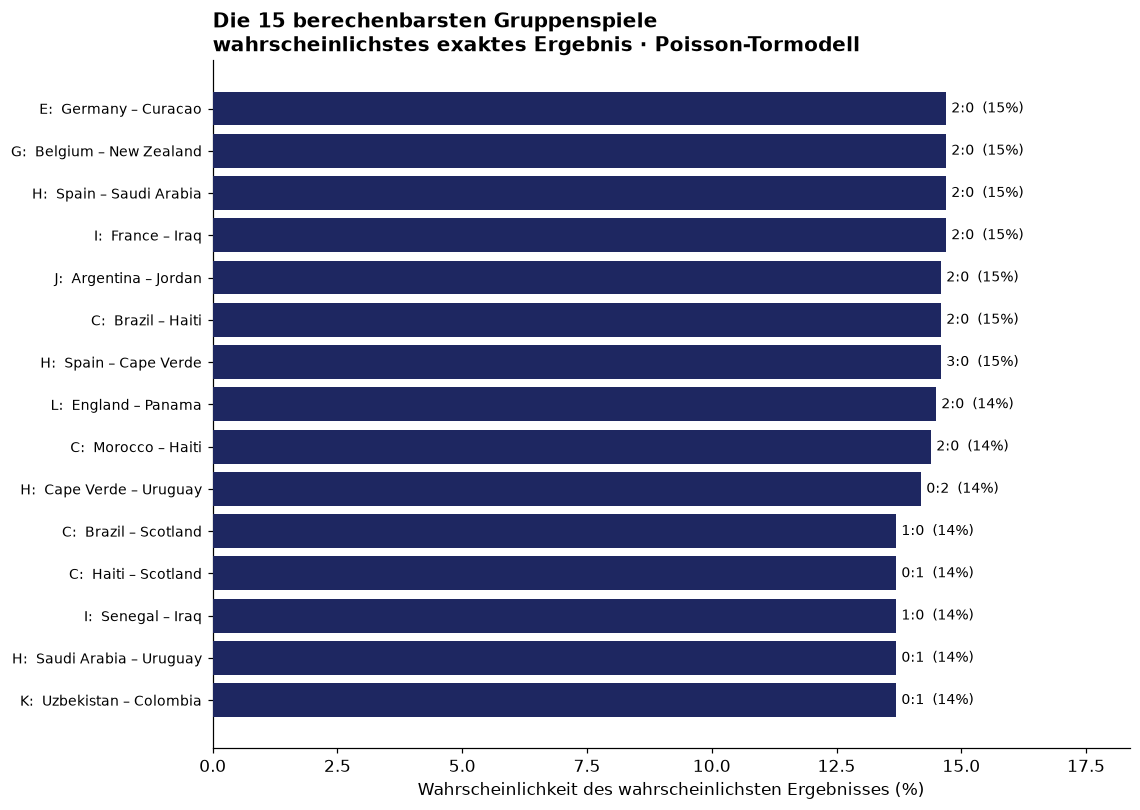

In [18]:
gp  = group_scores
lab = (gp[("Spiel", "Gr.")].astype(str) + ":  " + gp[("Spiel", "Begegnung")].astype(str)).values
pp  = gp[("Poisson", "P%")].astype(float).values
sc  = gp[("Poisson", "Erg.")].astype(str).values
o   = np.argsort(pp)[::-1][:15][::-1]
fig, ax = plt.subplots(figsize=(10.5, 7.5))
ax.barh(range(len(o)), pp[o], color=NAVY, zorder=3)
ax.set_yticks(range(len(o))); ax.set_yticklabels([lab[i] for i in o], fontsize=9)
for k, i in enumerate(o):
    ax.text(pp[i]+0.1, k, f"{sc[i]}  ({pp[i]:.0f}%)", va="center", fontsize=9)
ax.set_xlabel("Wahrscheinlichkeit des wahrscheinlichsten Ergebnisses (%)")
ax.set_title("Die 15 berechenbarsten Gruppenspiele\n"
             "wahrscheinlichstes exaktes Ergebnis · Poisson-Tormodell", loc="left")
ax.set_xlim(0, pp[o].max()*1.25)
plt.tight_layout(); plt.savefig("nb_group_predictable.png"); plt.show()


# Teil C — Turnier-Simulation: Wer gewinnt die WM?

Jetzt verknüpfen wir alles: Die W/D/N-Wahrscheinlichkeiten jedes Modells
speisen einen **vektorisierten Monte-Carlo-Simulator** (12 Gruppen → 8 beste
Gruppendritte → K.-o.-Runde mit 32 Teams). Wir simulieren das Turnier viele
tausend Mal und zählen die Titel.

In [19]:
n = len(TEAMS); ix = {t:i for i,t in enumerate(TEAMS)}

def build_matrices(keys):
    models = {}
    for key in [k for k in keys if k in ("poisson","negbin","elo","colley","pagerank")]:
        PW=np.zeros((n,n)); PD=np.zeros((n,n)); PL=np.zeros((n,n)); EGD=np.zeros((n,n))
        for a in TEAMS:
            for b in TEAMS:
                if a==b: continue
                i,j=ix[a],ix[b]
                if key in ("poisson","negbin"):
                    la,lb=lam(a,b); pw,pd_,pl=_grid_wdl(la,lb,nb=(key=="negbin")); egd=la-lb
                else:
                    S = STRENGTH if key=="elo" else (COLLEY if key=="colley" else PAGER)
                    da=S[a]-S[b]; we=elo_winexp(da); pdr=pdraw(abs(da))
                    pw=(1-pdr)*we; pl=(1-pdr)*(1-we); pd_=pdr; egd=da*EGD_PER
                PW[i,j],PD[i,j],PL[i,j],EGD[i,j]=pw,pd_,pl,egd
        models[key]={"PW":PW,"PD":PD,"PL":PL,"EGD":EGD}
    clf_keys=[k for k in keys if k in clf_classes]
    if clf_keys:
        pairs=[(i,j) for i in range(n) for j in range(n) if i!=j]
        feat=np.array([[STRENGTH[TEAMS[i]]-STRENGTH[TEAMS[j]],
                        STRENGTH[TEAMS[i]]+STRENGTH[TEAMS[j]], 0] for i,j in pairs], float)
        for key in clf_keys:
            clf,classes=clf_classes[key]; proba=clf.predict_proba(feat)
            cidx={c:k for k,c in enumerate(classes)}
            PW=np.zeros((n,n)); PD=np.zeros((n,n)); PL=np.zeros((n,n)); EGD=np.zeros((n,n))
            for r,(i,j) in enumerate(pairs):
                pl=proba[r,cidx.get(0,0)]; pd_=proba[r,cidx.get(1,0)]; pw=proba[r,cidx.get(2,0)]
                PW[i,j],PD[i,j],PL[i,j],EGD[i,j]=pw,pd_,pl,(pw-pl)*1.7
            models[key]={"PW":PW,"PD":PD,"PL":PL,"EGD":EGD}
    return models

# bracket helpers
gi=[[ix[t] for t in GROUPS[g]] for g in GROUPS]
def bracket_seed_order(N):
    s=[1,2]
    while len(s)<N:
        m=len(s)*2+1; s=[x for v in s for x in (v,m-v)]
    return s
SEED=bracket_seed_order(32)
STR_ARR=np.array([STRENGTH[t] for t in TEAMS], float)
LOCAL_PAIRS=[(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]
def _sort_by_strength(arr):
    o=np.argsort(-STR_ARR[arr], axis=1); return np.take_along_axis(arr,o,1)

def simulate(model, N=5000):
    PW,PD,PL,EGD=model["PW"],model["PD"],model["PL"],model["EGD"]
    win_g=[]; run_g=[]; third_t=[]; third_s=[]
    for grp in gi:
        gt=np.array(grp); pts=np.zeros((N,4)); gd=np.zeros((N,4))
        for a,b in LOCAL_PAIRS:
            i,j=grp[a],grp[b]; pw,pd_=PW[i,j],PD[i,j]
            u=rng.random(N); hw=u<pw; dr=(u>=pw)&(u<pw+pd_); aw=u>=pw+pd_
            pts[:,a]+=hw*3+dr; pts[:,b]+=aw*3+dr
            g=rng.normal(EGD[i,j],1.4,N); gd[:,a]+=g; gd[:,b]-=g
        score=pts*1000+gd+rng.random((N,4))*1e-3; order=np.argsort(-score,axis=1)
        win_g.append(gt[order[:,0]]); run_g.append(gt[order[:,1]])
        tl=order[:,2]; third_t.append(gt[tl])
        third_s.append(np.take_along_axis(pts,tl[:,None],1)[:,0]*1000
                       +np.take_along_axis(gd,tl[:,None],1)[:,0])
    winners=np.stack(win_g,1); runners=np.stack(run_g,1)
    tt=np.stack(third_t,1); ts=np.stack(third_s,1)
    bo=np.argsort(-ts,axis=1)[:,:8]; thirds=np.take_along_axis(tt,bo,1)
    seeded=np.concatenate([_sort_by_strength(winners),_sort_by_strength(runners),
                           _sort_by_strength(thirds)],axis=1)
    field=seeded[:, np.array(SEED)-1]
    while field.shape[1]>1:
        a=field[:,0::2]; b=field[:,1::2]
        pw=PW[a,b]; pl=PL[a,b]; p=np.where((pw+pl)>0, pw/(pw+pl+1e-12), 0.5)
        u=rng.random(a.shape); field=np.where(u<p, a, b)
    return np.bincount(field[:,0], minlength=n)/N*100
print("Simulator bereit.")

Simulator bereit.


### 6.1 Alle Modelle simulieren und Konsens bilden

In [20]:
N_SIM = 5000
SIM_KEYS = ["poisson","negbin","elo","colley","pagerank","logit","knn","rf","xgb","nn"]
MODELS = build_matrices(SIM_KEYS)
res = {}
for key in SIM_KEYS:
    res[key] = simulate(MODELS[key], N_SIM)
    print(f"  {key:9s} Top-Tipp: {TEAMS[int(np.argmax(res[key]))]}")

# Markt-Benchmark (Ch9): Quoten entvigen
dec = {t: 1+a/100 if a>0 else 1+100/(-a) for t,a in FUTURES_AMERICAN.items()}
imp = {t: 1/d for t,d in dec.items()}; ov = sum(imp.values())
market = {t: imp[t]/ov*100 for t in imp}
res["market"] = np.array([market.get(t, np.nan) for t in TEAMS])

title_df = pd.DataFrame({"Team": TEAMS, "Stärke":[STRENGTH[t] for t in TEAMS]})
for key in res: title_df[key] = res[key]
mcols = [c for c in SIM_KEYS]
title_df["Konsens"] = title_df[mcols].mean(1)
title_df = title_df.sort_values("Konsens", ascending=False).reset_index(drop=True)
print("\nKonsens-Titelwahrscheinlichkeit — Top 5:")
for _,r in title_df.head(5).iterrows():
    print(f"  {r.Team:12s} {r.Konsens:5.1f}%")

  poisson   Top-Tipp: Spain
  negbin    Top-Tipp: Spain
  elo       Top-Tipp: Spain
  colley    Top-Tipp: Netherlands
  pagerank  Top-Tipp: Spain
  logit     Top-Tipp: Spain
  knn       Top-Tipp: Spain
  rf        Top-Tipp: Argentina
  xgb       Top-Tipp: Argentina


  nn        Top-Tipp: France

Konsens-Titelwahrscheinlichkeit — Top 5:
  Spain         20.3%
  Argentina     14.0%
  France        13.9%
  Netherlands    9.8%
  England        9.6%


### 6.2 Titel-Wahrscheinlichkeit (Konsens-Tabelle)

In [21]:
show = ["Team","Stärke"] + mcols + ["Konsens"]
(title_df[show].head(12).style.hide(axis="index")
   .format({**{c:"{:.1f}" for c in mcols+["Konsens"]}, "Stärke":"{:.0f}"})
   .background_gradient(cmap="YlOrRd", subset=["Konsens"])
   .background_gradient(cmap="Blues", subset=mcols)
   .set_caption(f"Titelwahrscheinlichkeit (%) je Modell — Top 12 nach Konsens · {N_SIM:,} Simulationen/Modell"))

Team,Stärke,poisson,negbin,elo,colley,pagerank,logit,knn,rf,xgb,nn,Konsens
Spain,2165,26.6,26.8,28.2,13.2,29.6,27.1,14.5,11.8,14.3,10.7,20.3
Argentina,2120,18.0,17.3,19.4,8.8,3.0,19.2,14.2,13.8,15.2,11.4,14.0
France,2100,14.6,14.3,15.2,10.6,20.9,14.6,13.3,10.9,12.3,11.8,13.9
Netherlands,2030,5.8,6.4,5.8,18.0,17.3,6.3,9.6,8.7,9.6,10.0,9.8
England,2055,8.7,8.1,8.8,3.9,8.9,9.6,11.9,11.9,13.0,11.3,9.6
Brazil,2025,5.7,6.5,5.7,5.5,1.8,6.0,9.3,8.8,7.5,9.3,6.6
Portugal,2010,5.3,4.7,4.4,1.2,1.4,4.8,7.6,8.0,6.6,9.7,5.4
Germany,1965,3.0,3.3,2.3,5.4,10.7,2.2,4.3,6.0,6.5,5.9,5.0
Belgium,1950,2.2,2.0,1.9,6.3,1.7,1.9,3.4,4.2,4.5,4.9,3.3
Croatia,1945,1.7,2.0,1.7,0.8,0.7,1.5,2.8,3.0,1.5,3.2,1.9


### 6.3 Die Schlagzeile: Wer gewinnt die WM 2026?

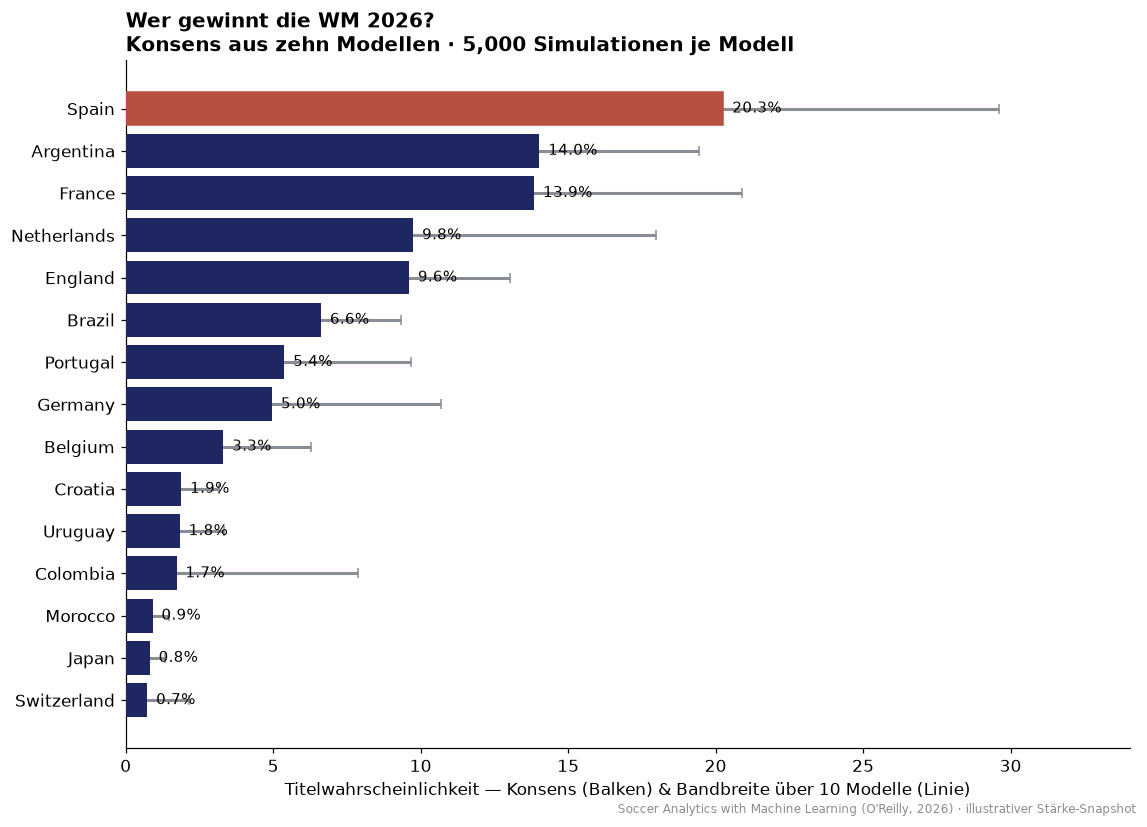

In [22]:
top = title_df.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(10.5, 7.5))
lo = title_df[mcols].min(1).reindex(top.index); hi = title_df[mcols].max(1).reindex(top.index)
bars = ax.barh(top["Team"], top["Konsens"], color=NAVY, zorder=3)
bars[-1].set_color(RED)
ax.hlines(range(len(top)), lo, hi, color=GREY, lw=2, zorder=2)        # Bandbreite über Modelle
ax.plot(lo, range(len(top)), "|", color=GREY); ax.plot(hi, range(len(top)), "|", color=GREY)
for i,(t,v) in enumerate(zip(top["Team"], top["Konsens"])):
    ax.text(v+0.3, i, f"{v:.1f}%", va="center", fontsize=10)
ax.set_xlabel("Titelwahrscheinlichkeit — Konsens (Balken) & Bandbreite über 10 Modelle (Linie)")
ax.set_title("Wer gewinnt die WM 2026?\nKonsens aus zehn Modellen · "
             f"{N_SIM:,} Simulationen je Modell", loc="left")
ax.set_xlim(0, hi.max()*1.15)
fig.text(0.99, 0.005, "Soccer Analytics with Machine Learning (O'Reilly, 2026) · illustrativer Stärke-Snapshot",
         ha="right", fontsize=8, color=GREY)
plt.tight_layout(); plt.savefig("nb_title_probabilities.png"); plt.show()

# Teil D — Beliebiges Match analysieren (interaktiv)

Eine Funktion, die alles zusammenfasst: gib zwei Teams an und erhalte
W/D/N-Konsens, die wahrscheinlichsten Ergebnisse und die Tor-zu-Tor-Heatmap.
Einfach Team-Namen ändern und Zelle neu ausführen.

══ France  vs  England  ══  (Modell für Ergebnis-Matrix: poisson)
Konsens über 11 Modelle:  France 35.3%  | Remis 30.2%  | England 34.5%
Erwartete Tore:  France 1.27 — 1.10 England   (Gesamt 2.37)
Wahrscheinlichste Ergebnisse:  1:1 (13.1%) · 1:0 (11.9%) · 0:1 (10.3%) · 0:0 (9.3%) · 2:1 (8.3%)
Über 2.5: 42%  | Unter 2.5: 58%  | BTTS: 48%


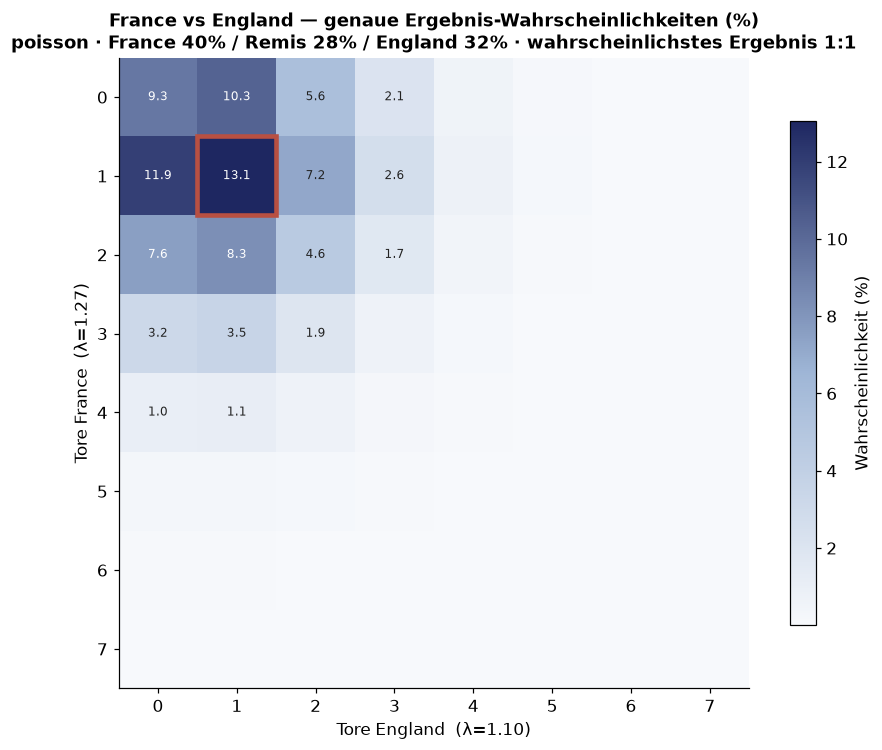

In [23]:
def analyse_match(a, b, model="poisson"):
    assert a in STRENGTH and b in STRENGTH, "Team unbekannt — siehe STRENGTH-Schlüssel"
    wdl = wdl_all_models(a, b); cons = wdl.mean()
    print(f"══ {a}  vs  {b}  ══  (Modell für Ergebnis-Matrix: {model})")
    print(f"Konsens über 11 Modelle:  {a} {cons['Sieg']:.1f}%  | "
          f"Remis {cons['Unentschieden']:.1f}%  | {b} {cons['Niederlage']:.1f}%")
    rep = match_report(a, b, model)
    print(f"Erwartete Tore:  {a} {rep['lam'][0]:.2f} — {rep['lam'][1]:.2f} {b}   "
          f"(Gesamt {rep['exp_total']:.2f})")
    print("Wahrscheinlichste Ergebnisse:  " +
          " · ".join(f"{s} ({p:.1f}%)" for s,p in rep["top_scores"][:5]))
    print(f"Über 2.5: {rep['over25']:.0f}%  | Unter 2.5: {rep['under25']:.0f}%  | "
          f"BTTS: {rep['btts']:.0f}%")
    return plot_scoreline(a, b, model)

_ = analyse_match("France", "England", "poisson")

══ Brazil  vs  Argentina  ══  (Modell für Ergebnis-Matrix: negbin)
Konsens über 11 Modelle:  Brazil 23.5%  | Remis 41.3%  | Argentina 35.2%
Erwartete Tore:  Brazil 1.01 — 1.38 Argentina   (Gesamt 2.39)
Wahrscheinlichste Ergebnisse:  1:1 (12.7%) · 0:1 (12.6%) · 1:0 (9.3%) · 0:0 (9.2%) · 1:2 (8.7%)
Über 2.5: 43%  | Unter 2.5: 57%  | BTTS: 47%


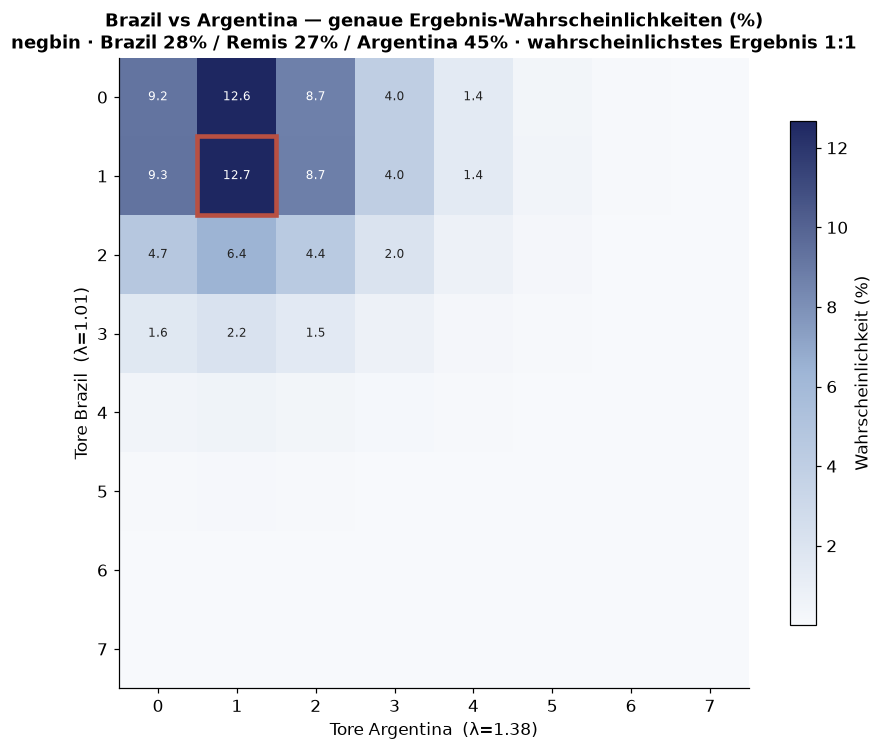

In [24]:
# Noch ein Beispiel — gerne eigene Teams einsetzen:
_ = analyse_match("Brazil", "Argentina", "negbin")

## Fazit & Einordnung

* **Sieg/Remis/Niederlage** (Teil A): jedes Match wird von elf Modellen bewertet.
  Bei klaren Favoriten sind sich die Modelle einig; bei engen Duellen
  (z. B. Niederlande–Deutschland) gehen die Schätzungen deutlich auseinander —
  genau diese Bandbreite ist der ehrliche Teil der Vorhersage.
* **Tor-zu-Tor** (Teil B): die vollständige Ergebnis-Matrix macht aus „Spanien
  ist Favorit" ein konkretes „wahrscheinlichstes Resultat 1:0, λ = 1.8 : 0.9,
  Über 2.5 = 47 %" — inklusive BTTS und Über/Unter.
* **Turnier** (Teil C): dieselben Match-Wahrscheinlichkeiten, 48 Teams, tausende
  Simulationen → Titelchancen samt Modell-Bandbreite.

> **Wichtig:** Stärke-Werte und Markt-Quoten sind ein illustrativer Snapshot.
> Für echte Prognosen die `STRENGTH`-Werte (z. B. von *eloratings.net*) und die
> `FUTURES_AMERICAN`-Quoten auffrischen und das Notebook neu ausführen.

*Aus* **Soccer Analytics with Machine Learning** *(O'Reilly, 2026) — Poisson &
Regression (Ch 4), Klassifikation (Ch 5), Bäume (Ch 6), neuronale Netze (Ch 7),
Team-Ratings (Ch 8), Markt/Quoten (Ch 9).*
